# Frobenius Motif Similarity Analysis

Visually cluster the cropped motif images in `frobenius_artifacts/analysis/motifs/` by appearance.

**Pipeline:**
1. Scan motif crops and load metadata from filenames
2. Embed every crop with **CLIP ViT-B/32** (512-dim, cosine space)
3. Cache embeddings so subsequent runs are instant
4. Project to 2-D with **t-SNE** for layout
5. Cluster with **HDBSCAN** for groupings
6. **Scatter map** — every motif as a thumbnail, neighbours are visually similar
7. **Cluster gallery** — grids of same-cluster motifs
8. **Cosine similarity heatmap**
9. **Nearest-neighbour explorer** — pick any motif, see its closest matches

```bash
uv run --project src/python jupyter notebook src/python/motif_similarity.ipynb
```

> Run `extract_crops.py` first if the motifs directory is empty.

In [7]:
# ── Cell 1: Colab setup (skip locally) ────────────────────────────────────
import sys
ON_COLAB = "google.colab" in sys.modules

if ON_COLAB:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "open-clip-torch", "hdbscan", "scikit-learn",
        "Pillow", "numpy>=1.24,<2", "ipywidgets",
    ], check=True)
    print("Colab: deps installed.")
else:
    print("Local — skipping Colab setup.")

Local — skipping Colab setup.


In [8]:
# ── Cell 2: imports & paths ────────────────────────────────────────────────
import sys, os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output

import torch
import open_clip

from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import hdbscan

# ── Paths ──────────────────────────────────────────────────────────────────
ON_COLAB = "google.colab" in sys.modules

if ON_COLAB:
    MOTIFS_DIR = Path("/content/motifs")
    CACHE_DIR  = Path("/content")
else:
    REPO_ROOT  = Path("../..")
    MOTIFS_DIR = REPO_ROOT / "frobenius_artifacts/analysis/motifs"
    CACHE_DIR  = Path(".")   # src/python/ — keeps cache next to notebook

EMBED_CACHE = CACHE_DIR / "motif_embeddings.npy"
PATHS_CACHE = CACHE_DIR / "motif_paths.txt"

print(f"Motifs dir : {MOTIFS_DIR.resolve()}")
print(f"Cache dir  : {CACHE_DIR.resolve()}")
if not MOTIFS_DIR.exists():
    print("WARNING: motifs directory not found — run extract_crops.py first.")

Motifs dir : /Users/korede/code/surulere/african-artifacts/frobenius_artifacts/analysis/motifs
Cache dir  : /Users/korede/code/surulere/african-artifacts/src/python


In [ ]:
# ── Cell 2.5: interactive normalization parameter tuner ───────────────────
#
# Pick 1–2 raw crops, tune the pipeline sliders, watch the preview update.
# When satisfied, click "Apply to All Motifs" to batch-run normalize_motifs.py
# with those parameters.
#
# Requires: cell 2 (REPO_ROOT); normalize_motifs.py next to this notebook.

import sys as _sys
import subprocess as _subprocess
import cv2 as _cv2_norm
import numpy as _np_norm
import matplotlib.pyplot as _plt_norm
import ipywidgets as _w2
from PIL import Image as _Image_norm
from IPython.display import display as _display2

# Import normalize_crop directly from the script (same directory as notebook)
_sys.path.insert(0, str(Path(".")))
from normalize_motifs import normalize_crop as _normalize_crop

_RAW_DIR  = REPO_ROOT / "frobenius_artifacts/analysis/motifs"
_NORM_DIR = REPO_ROOT / "frobenius_artifacts/analysis/motifs_norm"

if not _RAW_DIR.exists():
    print("WARNING: raw motifs directory not found — run extract_crops.py first.")
else:
    _all_crops = sorted(_RAW_DIR.rglob("*.png"))
    _labels    = [str(p.relative_to(_RAW_DIR)) for p in _all_crops]
    print(f"Found {len(_all_crops)} crops to preview from {_RAW_DIR.name}/")

# ── Widgets ───────────────────────────────────────────────────────────────
_sl3 = dict(continuous_update=False,
            style={"description_width": "170px"},
            layout=_w2.Layout(width="72%"))

w_crop1 = _w2.Dropdown(
    options=list(zip(_labels, _all_crops)),
    description="Crop 1:",
    style={"description_width": "60px"},
    layout=_w2.Layout(width="90%"),
)
w_crop2 = _w2.Dropdown(
    options=[("(none — single preview)", None)] + list(zip(_labels, _all_crops)),
    value=None,
    description="Crop 2:",
    style={"description_width": "60px"},
    layout=_w2.Layout(width="90%"),
)

w_shadow  = _w2.FloatSlider(min=5,   max=100, step=5,    value=40,
                description="shadow_sigma",    readout_format=".0f", **_sl3)
w_clahe   = _w2.FloatSlider(min=1.0, max=6.0, step=0.25, value=2.5,
                description="clahe_clip",      readout_format=".2f", **_sl3)
w_bilat   = _w2.IntSlider(  min=3,   max=15,  step=2,    value=7,
                description="bilateral_d",                           **_sl3)
w_dog_f   = _w2.FloatSlider(min=0.5, max=5.0, step=0.25, value=1.5,
                description="dog_sigma_fine",  readout_format=".2f", **_sl3)
w_dog_c   = _w2.FloatSlider(min=2.0, max=20.0,step=0.5,  value=8.0,
                description="dog_sigma_coarse",readout_format=".1f", **_sl3)
w_dog_w   = _w2.FloatSlider(min=0.0, max=1.5, step=0.05, value=0.7,
                description="dog_weight",      readout_format=".2f", **_sl3)

btn_apply   = _w2.Button(description="Apply to All Motifs",
                  button_style="success",
                  layout=_w2.Layout(width="220px", margin="10px 0 4px 0"))
out_preview = _w2.Output()
out_apply   = _w2.Output()


def _current_params():
    return dict(
        shadow_sigma    = w_shadow.value,
        clahe_clip      = w_clahe.value,
        bilateral_d     = w_bilat.value,
        dog_sigma_fine  = w_dog_f.value,
        dog_sigma_coarse= w_dog_c.value,
        dog_weight      = w_dog_w.value,
    )


def _update_preview(_=None):
    params = _current_params()
    paths  = [w_crop1.value]
    if w_crop2.value is not None:
        paths.append(w_crop2.value)

    n_rows = len(paths)
    fig, axes = _plt_norm.subplots(
        n_rows, 2,
        figsize=(11, 4.5 * n_rows),
        squeeze=False,
        facecolor="#111",
    )
    fig.subplots_adjust(wspace=0.04, hspace=0.25)

    for row, path in enumerate(paths):
        orig = _np_norm.array(_Image_norm.open(path).convert("RGB"))
        norm = _normalize_crop(orig, **params)
        rel  = path.relative_to(_RAW_DIR)

        for ax in axes[row]:
            ax.axis("off")
            ax.set_facecolor("#111")

        axes[row][0].imshow(orig)
        axes[row][0].set_title(f"original\n{rel}",
                                color="#ccc", fontsize=7, pad=5)

        axes[row][1].imshow(norm)
        axes[row][1].set_title(
            f"normalised\n"
            f"shadow={params['shadow_sigma']:.0f}  "
            f"dog=({params['dog_sigma_fine']:.1f},{params['dog_sigma_coarse']:.1f})×{params['dog_weight']:.2f}  "
            f"clahe={params['clahe_clip']:.2f}  bilat={params['bilateral_d']}",
            color="#ccc", fontsize=7, pad=5,
        )

    out_preview.clear_output(wait=True)
    with out_preview:
        _plt_norm.show()


def _apply_to_all(_):
    p = _current_params()
    cmd = [
        _sys.executable, str(Path(".") / "normalize_motifs.py"),
        f"--shadow-sigma={p['shadow_sigma']:.1f}",
        f"--clahe-clip={p['clahe_clip']:.2f}",
        f"--bilateral-d={p['bilateral_d']}",
        f"--dog-sigma-fine={p['dog_sigma_fine']:.2f}",
        f"--dog-sigma-coarse={p['dog_sigma_coarse']:.1f}",
        f"--dog-weight={p['dog_weight']:.2f}",
        "--force",
    ]
    out_apply.clear_output(wait=True)
    with out_apply:
        print("Running:", " ".join(cmd[2:]))   # skip interpreter path for brevity
        result = _subprocess.run(cmd, capture_output=True, text=True,
                                 cwd=str(Path(".")))
        print(result.stdout)
        if result.returncode != 0:
            print("STDERR:", result.stderr)
        else:
            print("Done — re-run cells 3+ to pick up the updated motifs_norm/ files.")


for _w in (w_crop1, w_crop2, w_shadow, w_clahe, w_bilat, w_dog_f, w_dog_c, w_dog_w):
    _w.observe(_update_preview, names="value")

btn_apply.on_click(_apply_to_all)

_display2(
    _w2.HTML("<h3 style='margin:6px 0 2px'>Normalization parameter tuner</h3>"),
    _w2.HTML("<b>Select crops to preview</b>"),
    w_crop1, w_crop2,
    _w2.HTML("<b>Pipeline parameters</b>"),
    w_shadow, w_clahe, w_bilat, w_dog_f, w_dog_c, w_dog_w,
    btn_apply, out_apply,
    _w2.HTML("<hr style='border-color:#444;margin:6px 0'>"),
    out_preview,
)
_update_preview()

In [ ]:
# ── Cell 3: scan motif crops & build metadata ──────────────────────────────
# Expected layout:
#   motifs/<panel_stem>/<NNN>_<scale>_iou<X.XXX>.png
#
# USE_NORMALIZED = True  → use motifs_norm/ (medium-agnostic, recommended)
# USE_NORMALIZED = False → use raw motifs/   (original crops, baseline)

USE_NORMALIZED = True

if ON_COLAB:
    _motifs_root = MOTIFS_DIR   # already set by cell 2 Colab branch
else:
    _motifs_root = REPO_ROOT / (
        "frobenius_artifacts/analysis/motifs_norm"
        if USE_NORMALIZED
        else "frobenius_artifacts/analysis/motifs"
    )

if not _motifs_root.exists():
    hint = "run normalize_motifs.py first" if USE_NORMALIZED else "run extract_crops.py first"
    print(f"WARNING: motifs directory not found — {hint}")
    print(f"  Expected: {_motifs_root.resolve()}")
else:
    MOTIFS_DIR = _motifs_root
    print(f"{'Normalised' if USE_NORMALIZED else 'Raw'} motifs: {MOTIFS_DIR.resolve()}")

records = []
for panel_dir in sorted(MOTIFS_DIR.iterdir()):
    if not panel_dir.is_dir():
        continue
    panel_name = panel_dir.name
    for img_path in sorted(panel_dir.glob("*.png")):
        stem   = img_path.stem          # e.g. "003_motif_iou0.889"
        parts  = stem.split("_")
        idx    = int(parts[0])
        scale  = parts[1]               # motif | register
        iou    = float(parts[2].replace("iou", ""))
        records.append({
            "path"    : img_path,
            "panel"   : panel_name,
            "index"   : idx,
            "scale"   : scale,
            "pred_iou": iou,
        })

panels = sorted(set(r["panel"] for r in records))
print(f"{len(records)} crops across {len(panels)} panels")
for p in panels:
    n = sum(1 for r in records if r["panel"] == p)
    print(f"  {p}: {n}")

In [10]:
# ── Cell 4: CLIP embeddings (cached, with preprocessing) ──────────────────
#
# PREPROCESS_MODE controls what is fed into CLIP:
#   "color"     — raw crop (CLIP default; biased toward tint/hue)
#   "grayscale" — strips all color; retains texture but not tone
#   "edges"     — Canny edge map; focuses purely on shape contours
#   "clahe"     — per-channel contrast normalisation; reduces brightness bias
#
# Change the mode and re-run this cell to recompute embeddings.
# Each mode caches separately so switching is fast after the first run.

import cv2 as _cv2

PREPROCESS_MODE = "grayscale"   # ← change me: color | grayscale | edges | clahe
CLIP_MODEL      = "ViT-B-32"
CLIP_WEIGHTS    = "openai"
BATCH           = 32

EMBED_CACHE = CACHE_DIR / f"motif_embeddings_{PREPROCESS_MODE}.npy"
PATHS_CACHE = CACHE_DIR / f"motif_paths_{PREPROCESS_MODE}.txt"


def preprocess_image(img: "PIL.Image") -> "PIL.Image":
    """Apply PREPROCESS_MODE transform before CLIP preprocessing."""
    img = img.convert("RGB")
    arr = np.array(img)

    if PREPROCESS_MODE == "color":
        return img

    elif PREPROCESS_MODE == "grayscale":
        gray = _cv2.cvtColor(arr, _cv2.COLOR_RGB2GRAY)
        return Image.fromarray(np.stack([gray] * 3, axis=-1))

    elif PREPROCESS_MODE == "edges":
        gray   = _cv2.cvtColor(arr, _cv2.COLOR_RGB2GRAY)
        # Adaptive Canny: auto-threshold from median intensity
        med    = float(np.median(gray))
        lo, hi = max(0, 0.5 * med), min(255, 1.5 * med)
        edges  = _cv2.Canny(gray, lo, hi)
        # White edges on black — invert so lines are dark on white (CLIP-friendlier)
        edges  = 255 - edges
        return Image.fromarray(np.stack([edges] * 3, axis=-1))

    elif PREPROCESS_MODE == "clahe":
        lab  = _cv2.cvtColor(arr, _cv2.COLOR_RGB2LAB).astype(np.uint8)
        cl   = _cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
        lab[:, :, 0] = cl.apply(lab[:, :, 0])
        return Image.fromarray(_cv2.cvtColor(lab, _cv2.COLOR_LAB2RGB))

    else:
        raise ValueError(f"Unknown PREPROCESS_MODE: {PREPROCESS_MODE!r}")


def _resolve_device():
    if torch.cuda.is_available(): return "cuda"
    return "cpu"

_clip_cache = {}

def get_clip():
    if not _clip_cache:
        device = _resolve_device()
        print(f"Loading CLIP {CLIP_MODEL} ({CLIP_WEIGHTS}) on {device}...")
        model, _, prep = open_clip.create_model_and_transforms(
            CLIP_MODEL, pretrained=CLIP_WEIGHTS
        )
        model = model.to(device).eval()
        _clip_cache.update({"model": model, "prep": prep, "device": device})
        print("CLIP ready.")
    return _clip_cache["model"], _clip_cache["prep"], _clip_cache["device"]


def compute_embeddings(recs):
    model, prep, device = get_clip()
    all_feats = []
    for i in range(0, len(recs), BATCH):
        batch = recs[i : i + BATCH]
        imgs  = torch.stack([
            prep(preprocess_image(Image.open(r["path"])))
            for r in batch
        ]).to(device)
        with torch.no_grad():
            feats = model.encode_image(imgs)
            feats = feats / feats.norm(dim=-1, keepdim=True)
        all_feats.append(feats.cpu().float().numpy())
        print(f"  {min(i + BATCH, len(recs))}/{len(recs)}", end="\r")
    print()
    return np.vstack(all_feats)


current_paths = [str(r["path"]) for r in records]

if (
    EMBED_CACHE.exists() and PATHS_CACHE.exists()
    and PATHS_CACHE.read_text().strip().split("\n") == current_paths
):
    print(f"Loading cached embeddings ({PREPROCESS_MODE})...")
    embeddings = np.load(EMBED_CACHE)
    print(f"  shape: {embeddings.shape}")
else:
    print(f"Computing CLIP embeddings (mode={PREPROCESS_MODE})...")
    embeddings = compute_embeddings(records)
    np.save(EMBED_CACHE, embeddings)
    PATHS_CACHE.write_text("\n".join(current_paths))
    print(f"Computed and cached: {embeddings.shape}")

print(f"\nPreprocess mode : {PREPROCESS_MODE}")
print(f"Embedding shape : {embeddings.shape}")


Loading cached embeddings (grayscale)...
  shape: (268, 512)

Preprocess mode : grayscale
Embedding shape : (268, 512)


In [ ]:
# ── Cell 4.5: embedding near-duplicate filter ─────────────────────────────
#
# Geometric containment (in extract_crops.py --filter-containment) removes
# sub-crops that overlap spatially.  This cell catches the remaining case:
# two crops framed slightly differently that represent the *same* motif —
# e.g. one detection includes a border strip the other doesn't.
#
# Method: for every pair with cosine_sim > SIM_THRESH, if the larger crop
# has area ≥ AREA_RATIO × the smaller's area, the smaller is a tighter
# re-crop of the same element → discard it, keep the larger.
#
# Set DEDUP_ENABLED = False to skip filtering (baseline comparison).

DEDUP_ENABLED = True
SIM_THRESH    = 0.97    # cosine similarity above which crops are "the same"
AREA_RATIO    = 1.4     # how much bigger the larger must be to count as a supercrop

import ipywidgets as _w
from IPython.display import display as _display

# ── Interactive controls ──────────────────────────────────────────────────
_sl2 = dict(continuous_update=False,
            style={"description_width": "160px"},
            layout=_w.Layout(width="55%"))

w_dedup     = _w.Checkbox(value=DEDUP_ENABLED,
                  description="Enable near-duplicate filter",
                  style={"description_width": "initial"})
w_sim_th    = _w.FloatSlider(min=0.90, max=1.00, step=0.005, value=SIM_THRESH,
                  readout_format=".3f", description="similarity threshold", **_sl2)
w_area_rat  = _w.FloatSlider(min=1.0,  max=3.0,  step=0.1,  value=AREA_RATIO,
                  readout_format=".1f", description="area ratio threshold", **_sl2)
out_dedup   = _w.Output()

# Area of each bbox in pixels (read from records via path metadata)
# We approximate from the crop image size rather than re-reading detections.json
def _crop_area(r):
    img = Image.open(r["path"])
    return img.width * img.height

print("Pre-loading crop areas for dedup filter...")
_areas = [_crop_area(r) for r in records]
print(f"  done ({len(_areas)} crops)")

# Index mask: True = keep, False = filtered out
_dedup_mask = np.ones(len(records), dtype=bool)


def run_dedup(enabled, sim_th, area_rat):
    global _dedup_mask
    mask = np.ones(len(records), dtype=bool)

    if enabled:
        sim = cosine_similarity(embeddings)   # already computed in cell 4
        n   = len(records)
        # Process pairs sorted by area (larger first keeps larger)
        order = sorted(range(n), key=lambda i: -_areas[i])
        for pos, i in enumerate(order):
            if not mask[i]:
                continue
            for j in order[pos + 1:]:
                if not mask[j]:
                    continue
                if sim[i, j] >= sim_th and _areas[i] >= area_rat * _areas[j]:
                    mask[j] = False   # j is smaller and nearly identical → drop

    _dedup_mask = mask
    kept    = int(mask.sum())
    removed = len(records) - kept

    out_dedup.clear_output(wait=True)
    with out_dedup:
        if enabled:
            print(f"Near-duplicate filter: removed {removed}, kept {kept}  "
                  f"[sim>{sim_th:.3f}, area_ratio>{area_rat:.1f}]")
            if removed > 0:
                dropped = [records[i] for i in range(len(records)) if not mask[i]]
                for r in dropped:
                    print(f"  dropped  #{r['index']:03d} {r['scale']} {_short_panel(r['panel'])}")
        else:
            print(f"Near-duplicate filter disabled — using all {kept} crops")


def _on_dedup_change(_=None):
    run_dedup(w_dedup.value, w_sim_th.value, w_area_rat.value)

for w in (w_dedup, w_sim_th, w_area_rat):
    w.observe(_on_dedup_change, names="value")

_display(w_dedup, w_sim_th, w_area_rat, out_dedup)


def active_records():
    """Records after near-duplicate filtering (used by cells 5+)."""
    return [r for r, keep in zip(records, _dedup_mask) if keep]

def active_embeddings():
    """Embedding matrix after near-duplicate filtering."""
    return embeddings[_dedup_mask]


# Trigger initial run — requires sim_matrix from cell 4 and _short_panel from cell 6.
# If _short_panel isn't defined yet, define a stub here.
try:
    _short_panel
except NameError:
    def _short_panel(name):
        for tok in name.split("_"):
            if tok and tok[0].isupper() and tok not in ("EBA", "Div", "FoA", "Ife"):
                return tok[:8]
        return name[-8:]

run_dedup(w_dedup.value, w_sim_th.value, w_area_rat.value)

In [ ]:
# ── Cell 5: t-SNE projection + clustering ─────────────────────────────────
#
# Two-pass clustering:
#   Pass 1 — HDBSCAN: finds high-density clusters; some points stay as noise
#   Pass 2 — AgglomerativeClustering on the noise points: forces every
#             remaining point into a subgroup (no noise left behind)
#
# Sliders update clustering instantly — t-SNE only runs once.
# Uses active_records() / active_embeddings() from cell 4.5 (dedup-filtered).

from sklearn.cluster import AgglomerativeClustering

_recs = active_records()
_embs = active_embeddings()
N     = len(_recs)

# ── t-SNE (run once) ──────────────────────────────────────────────────────
PERPLEXITY = min(30, max(5, N // 8))
print(f"Running t-SNE (n={N}, perplexity={PERPLEXITY})...")

import sklearn as _sklearn
_sk_ver  = tuple(int(x) for x in _sklearn.__version__.split(".")[:2])
_iter_kw = "max_iter" if _sk_ver >= (1, 5) else "n_iter"

tsne   = TSNE(n_components=2, perplexity=PERPLEXITY, metric="euclidean",
              random_state=42, init="pca", **{_iter_kw: 1500})
coords = tsne.fit_transform(_embs)
print("t-SNE done.")

# ── Cosine similarity matrix ──────────────────────────────────────────────
sim_matrix = cosine_similarity(_embs)

# ── Widgets ───────────────────────────────────────────────────────────────
_sl = dict(continuous_update=False,
           style={"description_width": "160px"},
           layout=widgets.Layout(width="55%"))

w_mcs    = widgets.IntSlider(min=2, max=20, step=1, value=3,
               description="min_cluster_size", **_sl)
w_ms     = widgets.IntSlider(min=1, max=10, step=1, value=1,
               description="min_samples", **_sl)
w_method = widgets.ToggleButtons(options=["leaf", "eom"], value="leaf",
               description="selection method",
               style={"description_width": "160px", "button_width": "70px"})
w_pass2  = widgets.Checkbox(value=True,
               description="Sub-cluster noise points (pass 2)",
               style={"description_width": "initial"})
w_nsub   = widgets.IntSlider(min=2, max=30, step=1, value=8,
               description="pass-2 sub-clusters", **_sl)

out_summary = widgets.Output()

_state = {"labels": None, "n_clusters": 0, "n_noise_raw": 0}


def run_clustering(mcs, ms, method, do_pass2, n_sub):
    # Pass 1: HDBSCAN
    cl  = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms,
                           metric="euclidean",
                           cluster_selection_method=method)
    lbl = cl.fit_predict(_embs).copy()
    nc1 = len(set(lbl)) - (1 if -1 in lbl else 0)
    nn  = int((lbl == -1).sum())

    # Pass 2: sub-cluster the noise
    nc2 = 0
    if do_pass2 and nn > 0:
        noise_idx  = np.where(lbl == -1)[0]
        n_sub_real = min(n_sub, len(noise_idx))
        sub_lbl    = AgglomerativeClustering(n_clusters=n_sub_real).fit_predict(
                         _embs[noise_idx])
        offset = nc1  # new cluster IDs start after HDBSCAN ones
        for i, ni in enumerate(noise_idx):
            lbl[ni] = offset + sub_lbl[i]
        nc2 = n_sub_real

    _state["labels"]      = lbl
    _state["n_clusters"]  = nc1 + nc2
    _state["n_noise_raw"] = nn

    out_summary.clear_output(wait=True)
    with out_summary:
        remaining_noise = int((lbl == -1).sum())
        print(f"Pass 1 (HDBSCAN)  — {nc1} clusters, {nn} noise  "
              f"[mcs={mcs}, ms={ms}, method={method}]")
        if do_pass2:
            print(f"Pass 2 (Agglom.)  — {nc2} sub-clusters from {nn} noise points")
        print(f"Total             — {nc1+nc2} clusters, {remaining_noise} unclustered\n")
        for c in sorted(set(lbl)):
            tag = "  noise" if c == -1 else \
                  f"  C{c:2d}{'*' if c >= nc1 else ' '}"   # * = pass-2 cluster
            bar = "█" * min(50, int((lbl == c).sum()))
            print(f"{tag}: {(lbl == c).sum():3d}  {bar}")


def _on_change(_=None):
    run_clustering(w_mcs.value, w_ms.value, w_method.value,
                   w_pass2.value, w_nsub.value)

for w in (w_mcs, w_ms, w_method, w_pass2, w_nsub):
    w.observe(_on_change, names="value")

display(
    widgets.HTML("<b>Pass 1 — HDBSCAN</b>"),
    w_mcs, w_ms, w_method,
    widgets.HTML("<b>Pass 2 — sub-cluster noise</b>"),
    w_pass2, w_nsub,
    out_summary,
)
run_clustering(w_mcs.value, w_ms.value, w_method.value,
               w_pass2.value, w_nsub.value)


def labels():
    """Current cluster label array (updated live by sliders)."""
    return _state["labels"]

In [ ]:
# ── Cell 6: similarity map — thumbnails on t-SNE axes ─────────────────────
# Re-run this cell after adjusting clustering in cell 5.
#
# Each motif is drawn at its t-SNE position as a thumbnail with:
#   - Coloured border = cluster
#   - Index label     = motif number within its panel
#   - City abbreviation shown below each image
#
# The figure is saved to motif_scatter_<mode>.png alongside the notebook.
# Resolution: large figure (28×22") + high DPI (160) for a crisp overview;
# tiles are intentionally small so the global clustering structure is visible.

lbl   = labels()           # current clustering from cell 5
_recs = active_records()   # dedup-filtered records from cell 4.5

THUMB  = 38      # px — keep small so the global layout stays readable
ZOOM   = 0.48    # OffsetImage zoom
FIG_W  = 28
FIG_H  = 22
DPI    = 160

_PALETTE   = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors)
_NOISE_COL = (0.45, 0.45, 0.45)

def cluster_color(l):
    return _NOISE_COL if l == -1 else _PALETTE[l % len(_PALETTE)]

def _short_panel(name):
    for tok in name.split("_"):
        if tok and tok[0].isupper() and tok not in ("EBA", "Div", "FoA", "Ife"):
            return tok[:8]
    return name[-8:]

# Load + square-pad thumbnails
print("Loading thumbnails...")
thumbs = []
for r in _recs:
    img = Image.open(r["path"]).convert("RGB")
    img.thumbnail((THUMB, THUMB))
    sq = Image.new("RGB", (THUMB, THUMB), (25, 25, 25))
    sq.paste(img, ((THUMB - img.width) // 2, (THUMB - img.height) // 2))
    thumbs.append(np.array(sq))

# ── Draw scatter ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), dpi=DPI)
ax.set_facecolor("#111")
fig.patch.set_facecolor("#111")

BORDER = 2
half   = ZOOM * THUMB / 2
for i, (x, y) in enumerate(coords):
    col = cluster_color(lbl[i])
    ax.add_patch(plt.Rectangle(
        (x - half - BORDER, y - half - BORDER),
        2 * half + 2 * BORDER, 2 * half + 2 * BORDER,
        color=col, zorder=1, linewidth=0,
    ))

for i, (thumb, (x, y)) in enumerate(zip(thumbs, coords)):
    ab = AnnotationBbox(OffsetImage(thumb, zoom=ZOOM), (x, y),
                        frameon=False, zorder=2)
    ax.add_artist(ab)

for i, (r, (x, y)) in enumerate(zip(_recs, coords)):
    ax.text(x, y - half - BORDER - 1,
            f"#{r['index']} {_short_panel(r['panel'])}",
            fontsize=3.2, color="white", ha="center", va="top",
            zorder=3, alpha=0.85)

ax.autoscale_view()
margin = THUMB * 1.2
ax.set_xlim(coords[:, 0].min() - margin, coords[:, 0].max() + margin)
ax.set_ylim(coords[:, 1].min() - margin, coords[:, 1].max() + margin)
ax.axis("off")

nc   = _state["n_clusters"]
nn   = _state["n_noise_raw"]
left = int((lbl == -1).sum())
ax.set_title(
    f"Motif similarity map  ·  {N} crops  ·  CLIP {CLIP_MODEL} ({PREPROCESS_MODE})  ·  "
    f"{nc} clusters  ·  {nn} noise→pass-2  ·  {left} unclustered",
    color="white", fontsize=11, pad=10,
)

legend_handles = []
if left > 0:
    legend_handles.append(mpatches.Patch(color=_NOISE_COL, label=f"unclustered ({left})"))
for c in sorted(set(lbl)):
    if c == -1: continue
    cnt = int((lbl == c).sum())
    legend_handles.append(mpatches.Patch(color=cluster_color(c), label=f"C{c} (n={cnt})"))
ax.legend(handles=legend_handles, loc="lower right", fontsize=6.5,
          facecolor="#222", labelcolor="white", framealpha=0.85,
          ncols=max(1, len(legend_handles) // 16))

plt.tight_layout()

out_png = CACHE_DIR / f"motif_scatter_{PREPROCESS_MODE}.png"
fig.savefig(out_png, dpi=DPI, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Saved → {out_png}  ({FIG_W}×{FIG_H}\" @ {DPI} DPI = "
      f"{int(FIG_W*DPI)}×{int(FIG_H*DPI)}px)")
plt.show()

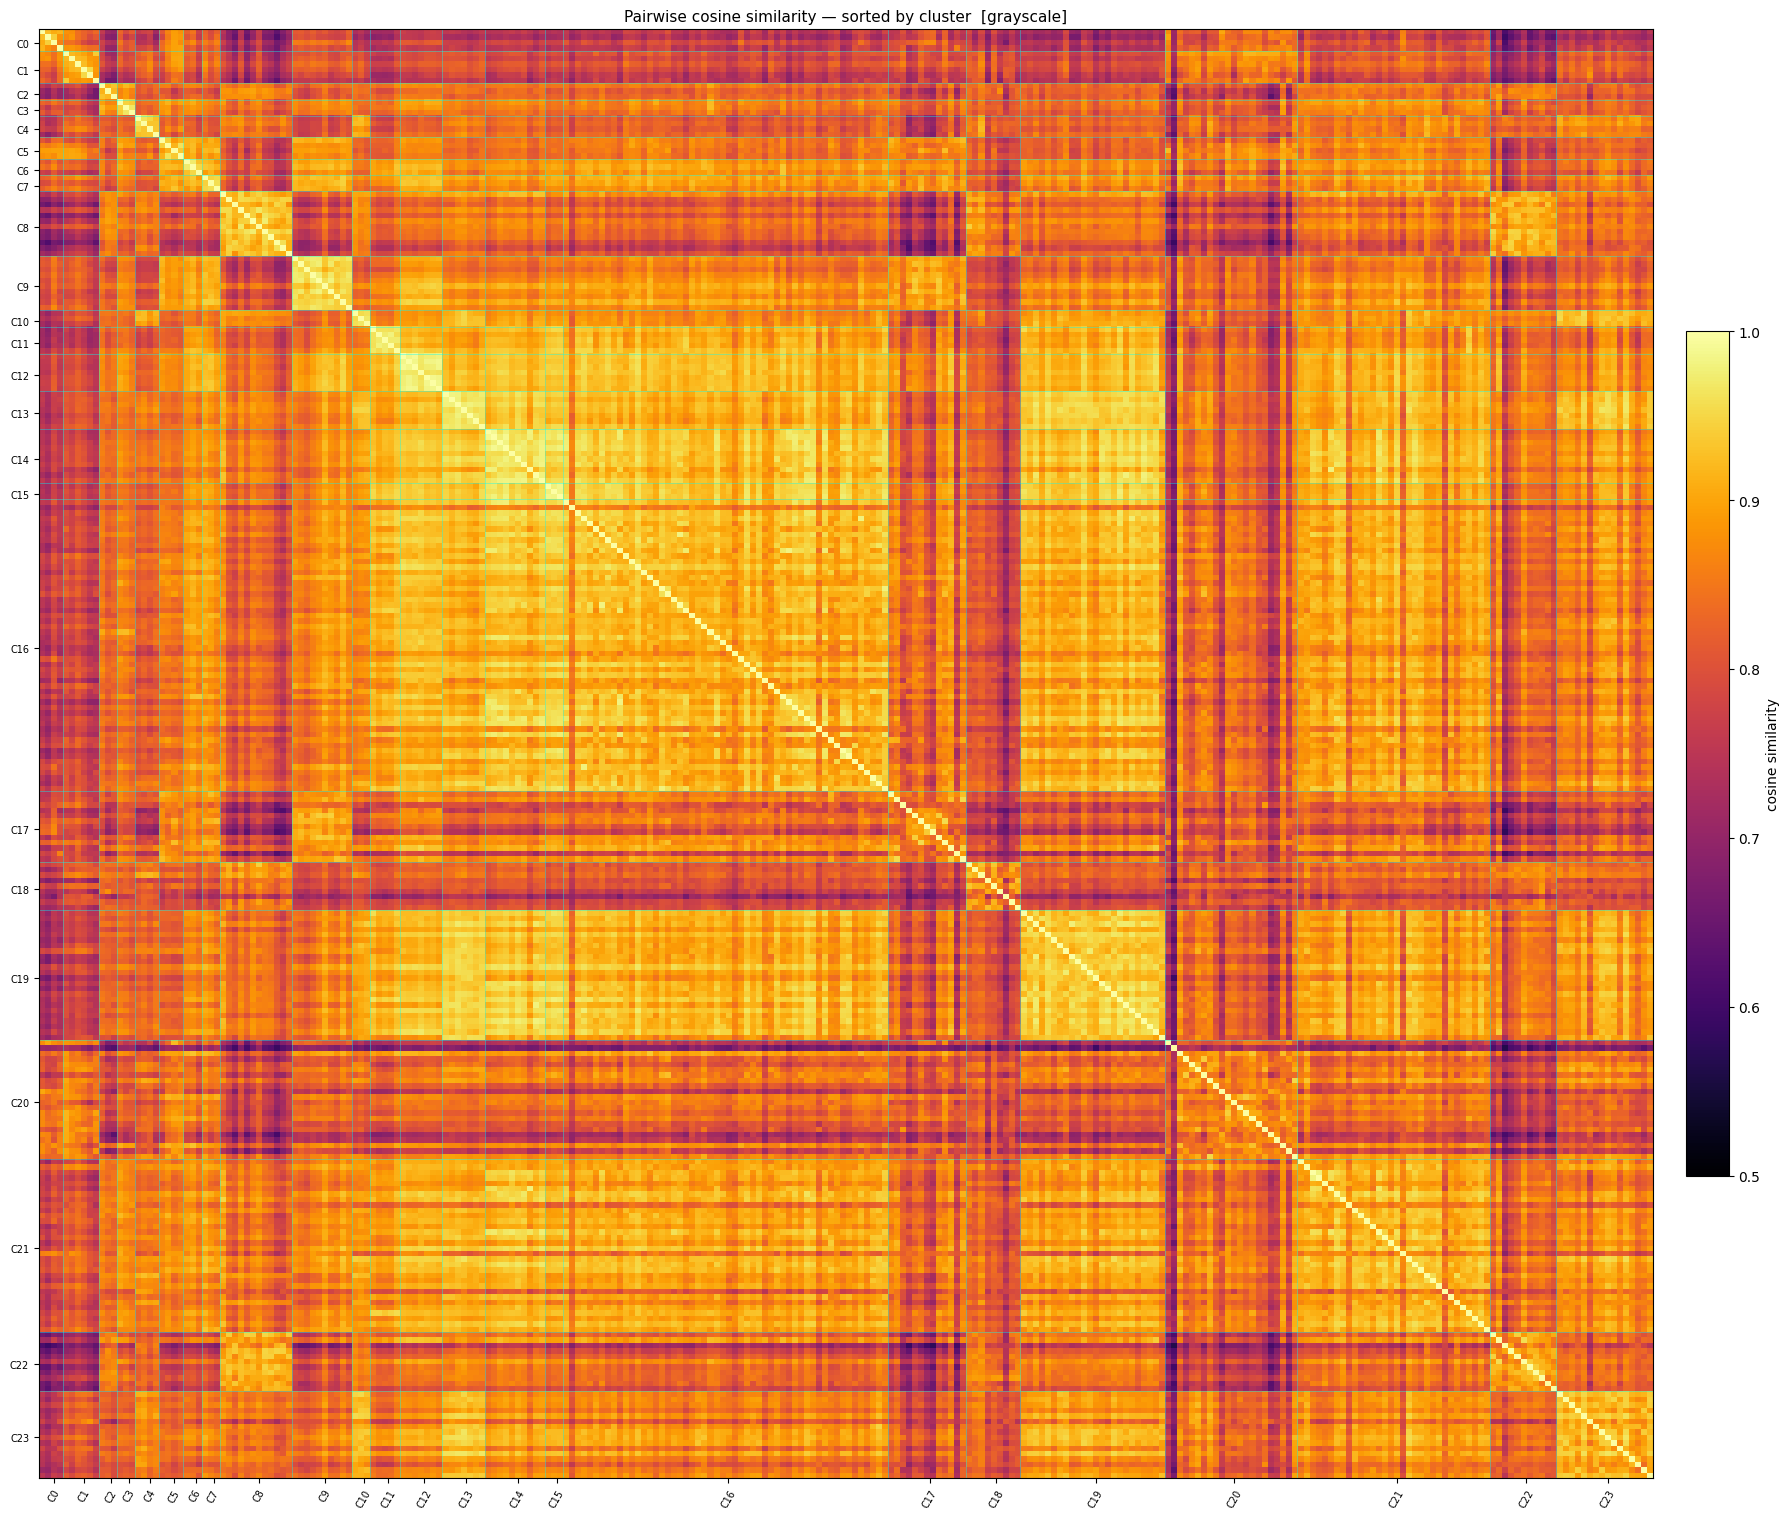

In [14]:
# ── Cell 7: cosine similarity heatmap ─────────────────────────────────────
# Re-run after adjusting clustering in cell 5.

lbl = labels()
order       = np.argsort(lbl)
sim_sorted  = sim_matrix[np.ix_(order, order)]
sorted_lbls = lbl[order]

# Cluster boundary positions
boundaries = [0]
for i in range(1, N):
    if sorted_lbls[i] != sorted_lbls[i - 1]:
        boundaries.append(i)
boundaries.append(N)

fig_size = min(18, max(8, N / 14))
fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.85))
im = ax.imshow(sim_sorted, cmap="inferno", vmin=0.5, vmax=1.0, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="cosine similarity")

for b in boundaries[1:-1]:
    ax.axhline(b - 0.5, color="cyan", lw=0.5, alpha=0.55)
    ax.axvline(b - 0.5, color="cyan", lw=0.5, alpha=0.55)

tick_pos  = [(boundaries[i] + boundaries[i + 1]) / 2 for i in range(len(boundaries) - 1)]
tick_lbls = ["noise" if sorted_lbls[int(p)] == -1 else f"C{sorted_lbls[int(p)]}"
             for p in tick_pos]
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_lbls, rotation=60, fontsize=7)
ax.set_yticks(tick_pos); ax.set_yticklabels(tick_lbls, fontsize=7)
ax.set_title(f"Pairwise cosine similarity — sorted by cluster  [{PREPROCESS_MODE}]", fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
# ── Cell 8: cluster gallery ────────────────────────────────────────────────
# Re-run after adjusting clustering in cell 5.

lbl   = labels()
_recs = active_records()

GALLERY_THUMB = 80
MAX_COLS      = 20
cluster_ids   = sorted(c for c in set(lbl) if c != -1) + ([-1] if -1 in lbl else [])

_embs = active_embeddings()

for c in cluster_ids:
    idx_in_c = [i for i, l in enumerate(lbl) if l == c]
    centroid = _embs[idx_in_c].mean(axis=0)
    centroid /= np.linalg.norm(centroid) + 1e-8
    order_c  = np.argsort(-(_embs[idx_in_c] @ centroid))
    idx_in_c = [idx_in_c[j] for j in order_c]

    tag   = f"Cluster {c}" if c != -1 else "Unclustered (noise)"
    color = cluster_color(c)
    n     = len(idx_in_c)
    n_cols = min(n, MAX_COLS)
    n_rows = (n + n_cols - 1) // n_cols
    fig_w  = n_cols * (GALLERY_THUMB / 72)
    fig_h  = n_rows * (GALLERY_THUMB / 72) + 0.5

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), squeeze=False)
    fig.patch.set_facecolor("#1a1a1a")
    fig.suptitle(f"{tag}  (n={n})", color="white", fontsize=9, x=0.02, ha="left", y=1.01)

    for row in axes:
        for ax in row:
            ax.axis("off"); ax.set_facecolor("#1a1a1a")

    for j, gi in enumerate(idx_in_c):
        r_ax = axes[j // n_cols][j % n_cols]
        r_ax.imshow(Image.open(_recs[gi]["path"]).convert("RGB"))
        r_ax.set_title(
            f"#{_recs[gi]['index']} {_short_panel(_recs[gi]['panel'])}",
            fontsize=4.5, color="white", pad=1.5,
        )
        for spine in r_ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(1.5); spine.set_visible(True)

    plt.tight_layout(pad=0.2)
    plt.show()

In [ ]:
# ── Cell 9: nearest-neighbour explorer ────────────────────────────────────

_recs = active_records()
TOP_K = 12

def _label(r, i):
    return f"{_short_panel(r['panel'])} / #{r['index']:03d} {r['scale']} (iou={r['pred_iou']:.2f})"

picker = widgets.Dropdown(
    options=[(_label(r, i), i) for i, r in enumerate(_recs)],
    value=0,
    description="Query:",
    layout=widgets.Layout(width="80%"),
    style={"description_width": "55px"},
)
w_k = widgets.IntSlider(
    min=4, max=40, step=2, value=TOP_K,
    description="Top K:",
    continuous_update=False,
    style={"description_width": "55px"},
    layout=widgets.Layout(width="40%"),
)
w_filter_cluster = widgets.Checkbox(
    value=False,
    description="Same cluster only",
    style={"description_width": "initial"},
)
out_nn = widgets.Output()

def _show_nn(query_idx, k, same_cluster_only):
    out_nn.clear_output(wait=True)
    lbl  = labels()
    sims = sim_matrix[query_idx].copy()
    sims[query_idx] = -1

    if same_cluster_only and lbl[query_idx] != -1:
        sims[lbl != lbl[query_idx]] = -1

    top_idx = np.argsort(-sims)[:k]
    top_sim = sims[top_idx]

    n_cols = min(k, 8)
    n_rows = 1 + (k + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.8),
                             squeeze=False)
    fig.patch.set_facecolor("#1a1a1a")
    for row in axes:
        for ax in row:
            ax.axis("off"); ax.set_facecolor("#1a1a1a")

    qr = _recs[query_idx]
    axes[0][0].imshow(Image.open(qr["path"]).convert("RGB"))
    qlbl = lbl[query_idx]
    axes[0][0].set_title(
        f"QUERY  #{qr['index']} {qr['scale']}\n{_short_panel(qr['panel'])}\n"
        f"{'C'+str(qlbl) if qlbl != -1 else 'noise'}",
        fontsize=6, color="white", pad=2,
    )
    for spine in axes[0][0].spines.values():
        spine.set_edgecolor("gold"); spine.set_linewidth(2); spine.set_visible(True)
    for col in range(1, n_cols):
        axes[0][col].set_visible(False)

    for j, (ni, sv) in enumerate(zip(top_idx, top_sim)):
        row = 1 + j // n_cols
        col = j % n_cols
        nr  = _recs[ni]
        nlbl = lbl[ni]
        axes[row][col].imshow(Image.open(nr["path"]).convert("RGB"))
        axes[row][col].set_title(
            f"sim={sv:.3f}\n#{nr['index']} {nr['scale']}\n{_short_panel(nr['panel'])}",
            fontsize=5, color="white", pad=2,
        )
        for spine in axes[row][col].spines.values():
            spine.set_edgecolor(cluster_color(nlbl)); spine.set_linewidth(1.5); spine.set_visible(True)

    plt.suptitle(
        f"Top-{k} nearest neighbours  [{PREPROCESS_MODE}]",
        color="white", fontsize=9, y=1.01,
    )
    plt.tight_layout(pad=0.4)
    with out_nn:
        plt.show()

def _on_change(_):
    _show_nn(picker.value, w_k.value, w_filter_cluster.value)

picker.observe(_on_change, names="value")
w_k.observe(_on_change, names="value")
w_filter_cluster.observe(_on_change, names="value")

display(
    widgets.HTML("<h3 style='margin-bottom:4px'>Nearest-neighbour explorer</h3>"),
    picker,
    widgets.HBox([w_k, w_filter_cluster]),
    out_nn,
)
_show_nn(picker.value, w_k.value, w_filter_cluster.value)